In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
import os
os.getcwd()

'c:\\Users\\Madhu\\Desktop\\Healthcare-KPI-Dashboard\\notebooks'

In [4]:
df = pd.read_csv("../data/modified_healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby Jackson,19,Female,AB+,Infections,2024-01-31,Matthew Smith,Northwestern Memorial Hospital,Blue Cross,2212.272701,328,Emergency,2024-02-07,Azithromycin,Normal,7
1,Leslie Terry,15,Female,B-,Flu,2019-08-20,Samantha Davies,UI Health (University of Illinois Hospital),UnitedHealthcare,3185.161388,265,Emergency,2019-08-22,Tamiflu,Abnormal,2
2,Danny Smith,50,Female,A+,Cancer,2022-09-22,Tiffany Mitchell,UI Health (University of Illinois Hospital),Blue Cross,72055.214065,205,Elective,2022-10-30,Cisplatin,Inconclusive,38
3,Andrew Watts,24,Female,O+,Asthma,2020-11-18,Kevin Wells,UI Health (University of Illinois Hospital),Aetna,4092.601229,450,Elective,2020-11-19,Prednisone,Normal,1
4,Adrienne Bell,80,Female,A+,Heart Disease,2022-09-19,Kathleen Hanna,Northwestern Memorial Hospital,Cigna,47985.660254,458,Routine,2022-10-27,Beta-blockers,Inconclusive,38


In [5]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results', 'Length of Stay'],
      dtype='str')

In [6]:
df["Medical Condition"].value_counts()

Medical Condition
Flu              7046
Diabetes         7005
Obesity          6994
Cancer           6940
Asthma           6908
Heart Disease    6900
Alzheimer’s      6861
Infections       6846
Name: count, dtype: int64

In [7]:
condition_counts = df["Medical Condition"].value_counts().reset_index()

condition_counts.columns = ["Medical Condition", "Patient Count"]

condition_counts

,Medical Condition,Patient Count
0,Flu,7046
1,Diabetes,7005
2,Obesity,6994
3,Cancer,6940
4,Asthma,6908
5,Heart Disease,6900
6,Alzheimer’s,6861
7,Infections,6846


## Insights: Medical Condition (Patient Count Analysis)
- Patient distribution is fairly balanced across all conditions.
- Flu, Diabetes, and Obesity have slightly higher counts.
- Cancer, Asthma, and Heart Disease are close in prevalence.
- Alzheimer’s and Infections are slightly lower but still comparable.
- No single condition dominates the dataset.


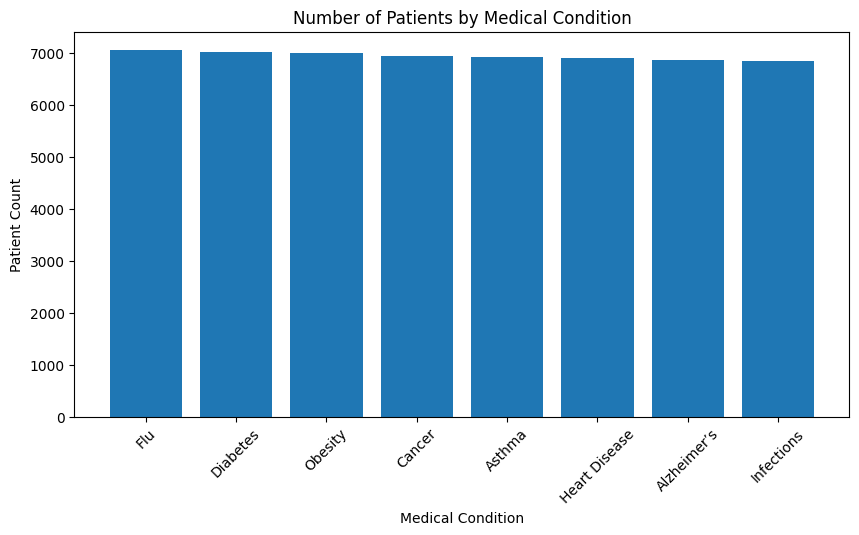

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    condition_counts["Medical Condition"],
    condition_counts["Patient Count"]
)

plt.title("Number of Patients by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Patient Count")

plt.xticks(rotation=45)
plt.show()

In [9]:
billing_kpi = df.groupby("Medical Condition")["Billing Amount"].mean().sort_values(ascending=False)

billing_kpi

Medical Condition
Cancer           64537.088667
Heart Disease    44913.427049
Alzheimer’s      32543.542291
Diabetes         12503.188470
Obesity          10055.563055
Asthma            5025.348290
Infections        2747.567493
Flu               2744.152050
Name: Billing Amount, dtype: float64

## Insights: Billing Amount by Medical Condition
- Cancer has the highest treatment cost, followed by Heart Disease and Alzheimer’s.
- Diabetes and Obesity show moderate billing amounts.
- Flu and Infections have the lowest costs.
- Chronic diseases drive significantly higher healthcare expenses.
- Strong variation exists in treatment cost across conditions.


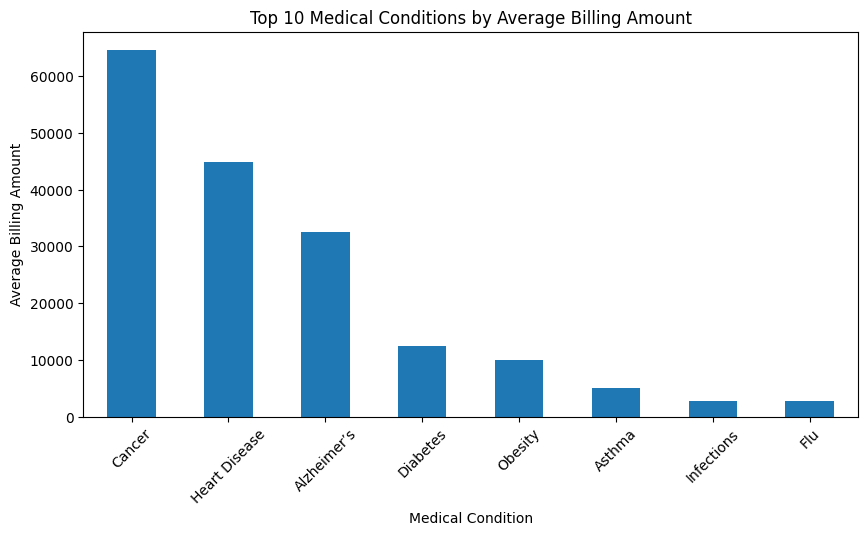

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

billing_kpi.head(10).plot(kind="bar")

plt.title("Top 10 Medical Conditions by Average Billing Amount")
plt.xlabel("Medical Condition")
plt.ylabel("Average Billing Amount")

plt.xticks(rotation=45)
plt.show()

In [11]:
hospital_kpi = df["Hospital"].value_counts().head(10)
hospital_kpi

Hospital
Northwestern Memorial Hospital                 14070
UI Health (University of Illinois Hospital)    13950
UChicago Medicine                              13870
Loyola University Medical Center               13610
Name: count, dtype: int64

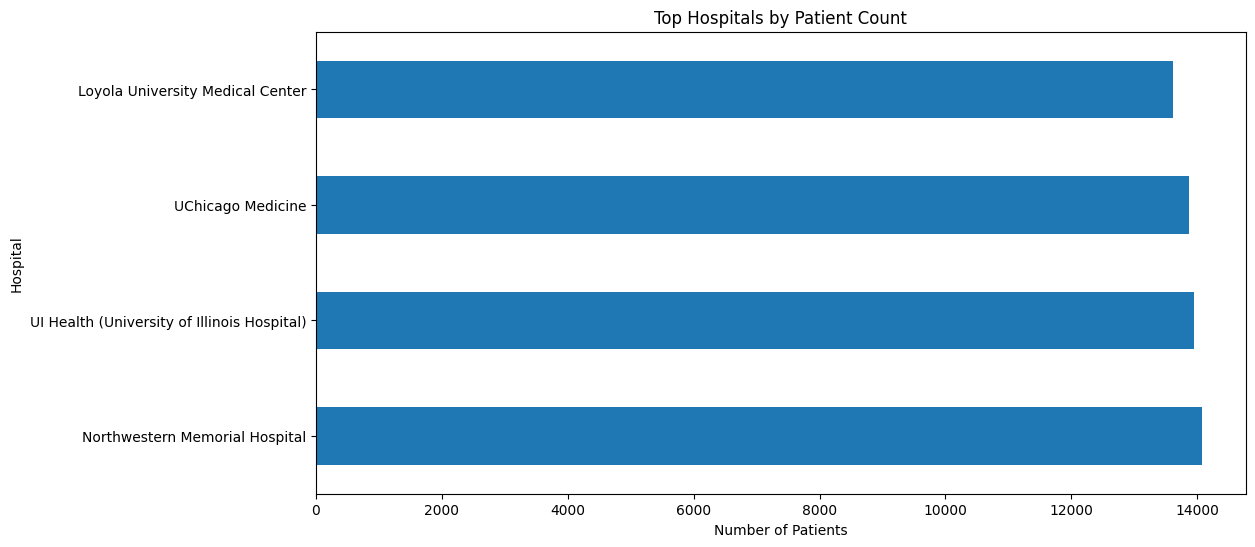

In [12]:
plt.figure(figsize=(12,6))

hospital_kpi.plot(kind="barh")

plt.title("Top Hospitals by Patient Count")
plt.xlabel("Number of Patients")
plt.ylabel("Hospital")

plt.show()

## Insights: Hospital Analysis
- Northwestern Memorial Hospital has the highest patient count
- UI Health and UChicago Medicine also show high patient volumes
- Patient load is fairly balanced across top hospitals
- No single hospital dominates overall demand
- Insights can support capacity and resource planning

In [13]:
los_kpi = df.groupby("Medical Condition")["Length of Stay"].mean().sort_values(ascending=False)

los_kpi

Medical Condition
Alzheimer’s      54.417286
Cancer           36.543804
Heart Disease    26.860580
Diabetes          8.063098
Obesity           5.966400
Infections        5.521911
Asthma            3.503619
Flu               2.504967
Name: Length of Stay, dtype: float64

## Insights: Length of Stay Analysis
- Alzheimer’s has the highest average hospital stay, followed by Cancer and Heart Disease
- Flu and Asthma have the shortest hospital stays, indicating less severe treatment requirements
- Chronic and long-term conditions result in significantly longer hospital stays
- This highlights differences in disease severity and hospital resource utilization
- Length of stay insights can support hospital capacity planning and resource management


In [14]:
summary = df.groupby("Medical Condition").agg({
    "Billing Amount": "mean",
    "Length of Stay": "mean",
    "Name": "count"
}).rename(columns={"Name": "Patient Count"})

summary

,Billing Amount,Length of Stay,Patient Count
Medical Condition,,,
Alzheimer’s,32543.542291,54.417286,6861
Asthma,5025.348290,3.503619,6908
Cancer,64537.088667,36.543804,6940
Diabetes,12503.188470,8.063098,7005
Flu,2744.152050,2.504967,7046
Heart Disease,44913.427049,26.860580,6900
Infections,2747.567493,5.521911,6846
Obesity,10055.563055,5.966400,6994


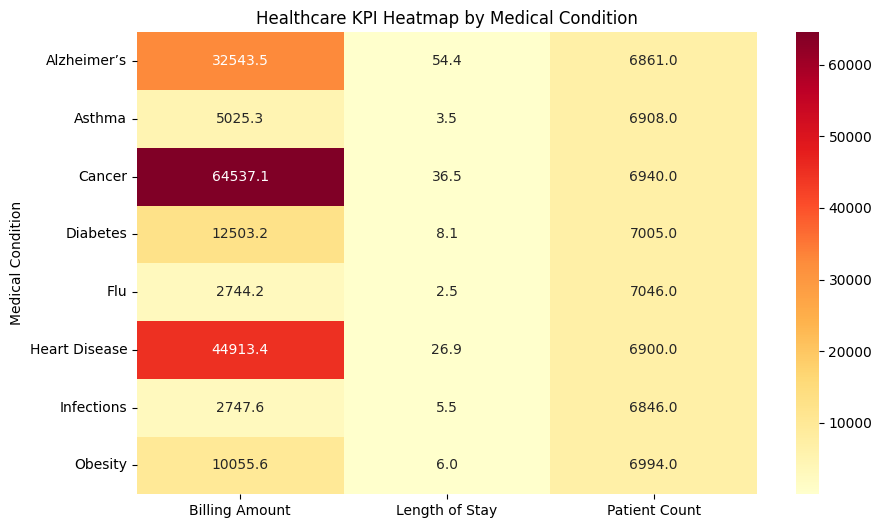

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(summary, annot=True, fmt=".1f", cmap="YlOrRd")

plt.title("Healthcare KPI Heatmap by Medical Condition")
plt.show()

## Insights: Multi-KPI Heatmap Analysis
- Cancer and Heart Disease show both high average billing and longer hospital stays, indicating high-cost and high-resource conditions
- Alzheimer’s shows the longest average length of stay, suggesting long-term care requirements
- Flu and Asthma consistently show low billing amounts and shorter hospital stays, indicating low resource usage
- Patient volume, cost, and length of stay vary significantly across medical conditions, highlighting differences in disease severity and healthcare demand
- The combined view helps identify high-impact medical conditions that require priority resource allocation

Will do further analysis 